In [1]:
import gzip
import json
import pandas as pd
from pathlib import Path

# Configs: paths & batch size
file_path = "/home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/data/Electronics_5.json.gz"
output_dir = Path("/home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews")

In [2]:

output_dir.mkdir(parents=True, exist_ok=True)
batch_size = 50_000

def review_is_valid(review):
    return (
        review.get("reviewText") and review.get("summary") and review.get("overall") is not None
        and review["reviewText"].strip() != ""
    )

# Step 1: Batch process loading and cleaning
def process_batches():
    rows = []
    total = 0
    kept = 0
    part = 0

    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for line in f:
            total += 1
            review = json.loads(line)
            if review_is_valid(review):
                rows.append(review)
                kept += 1

            if len(rows) >= batch_size:
                df_batch = pd.DataFrame(rows)
                part_path = output_dir / f"part_{part:04d}.parquet"
                df_batch.to_parquet(part_path, index=False, compression="snappy", engine="pyarrow")
                print(f"Wrote {len(rows)} rows to {part_path}")
                rows.clear()
                part += 1

        # write leftover
        if rows:
            df_batch = pd.DataFrame(rows)
            part_path = output_dir / f"part_{part:04d}.parquet"
            df_batch.to_parquet(part_path, index=False, compression="snappy", engine="pyarrow")
            print(f"Wrote final {len(rows)} rows to {part_path}")

    print(f"Processed {total} reviews, kept {kept} clean reviews.")

# Run batch processing (execute this cell to process)
process_batches()



Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0000.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0001.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0002.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0003.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0004.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0005.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/notebook_clean_reviews/part_0006.parquet
Wrote 50000 rows to /home/ianli/homl-self/public_showcase/ecommerce_l

In [3]:
# Load a small batch file for exploration
sample_file = output_dir / "part_0000.parquet"
df_sample = pd.read_parquet(sample_file)

print("Columns:", df_sample.columns.tolist())
df_sample.head()


Columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']


,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5.0,67,True,"09 18, 1999",AAP7PPBU72QFM,0151004714,"{'Capacity:': None, 'Color Name:': None, 'Colo...",D. C. Carrad,This is the best novel I have read in 2 or 3 y...,A star is born,937612800,None
1,3.0,5,True,"10 23, 2013",A2E168DTVGE6SV,0151004714,"{'Capacity:': None, 'Color Name:': None, 'Colo...",Evy,"Pages and pages of introspection, in the style...",A stream of consciousness novel,1382486400,None
2,5.0,4,False,"09 2, 2008",A1ER5AYS3FQ9O3,0151004714,"{'Capacity:': None, 'Color Name:': None, 'Colo...",Kcorn,This is the kind of novel to read when you hav...,I'm a huge fan of the author and this one did ...,1220313600,None
3,5.0,13,False,"09 4, 2000",A1T17LMQABMBN5,0151004714,"{'Capacity:': None, 'Color Name:': None, 'Colo...",Caf Girl Writes,What gorgeous language! What an incredible wri...,The most beautiful book I have ever read!,968025600,None
4,3.0,8,True,"02 4, 2000",A3QHJ0FXK33OBE,0151004714,"{'Capacity:': None, 'Color Name:': None, 'Colo...",W. Shane Schmidt,I was taken in by reviews that compared this b...,A dissenting view--In part.,949622400,None


In [3]:
df_sample = pd.read_parquet("/home/ianli/homl-self/public_showcase/ecommerce_llm_recommender/outputs/documents_part_000.parquet")

print("Columns:", df_sample.columns.tolist())
df_sample.head()

Columns: ['id', 'text', 'metadata.asin', 'metadata.overall', 'metadata.rating_label', 'metadata.review_length', 'metadata.verified', 'metadata.reviewTime', 'metadata.reviewerID', 'metadata.reviewerName', 'metadata.has_votes', 'metadata.votes', 'metadata.vote_bin']


,id,text,metadata.asin,metadata.overall,metadata.rating_label,metadata.review_length,metadata.verified,metadata.reviewTime,metadata.reviewerID,metadata.reviewerName,metadata.has_votes,metadata.votes,metadata.vote_bin
0,B00000J0MS_A16UWVFV9SF9FL,If I could give more than 5 stars I would. I ...,B00000J0MS,5.0,positive,229,False,"05 21, 2016",A16UWVFV9SF9FL,Thompson Family,False,NaN,missing
1,9983891204_A27ELSBLEUKFMH,works exactly as advertised. connects tablet t...,9983891204,5.0,positive,20,True,"04 3, 2014",A27ELSBLEUKFMH,1 day,False,NaN,missing
2,1416593535_A3QVAKVRAH657N,"In the early 1980s, Martin Cruz Smith and Stua...",1416593535,3.0,neutral,494,False,"03 1, 2009",A3QVAKVRAH657N,Orrin C. Judd,False,NaN,missing
3,9985519256_A13AMTIGRKFG9K,"great band saw blade for the price, smooth cut...",9985519256,5.0,positive,29,True,"11 25, 2012",A13AMTIGRKFG9K,Jesse James,False,NaN,missing
4,9983039281_A3202C86H3AD1V,First one I ordered didn't work. Sent it back ...,9983039281,1.0,negative,55,True,"09 15, 2010",A3202C86H3AD1V,Citris1,False,NaN,missing


<div class="alert alert-block alert-info">
EDA

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno

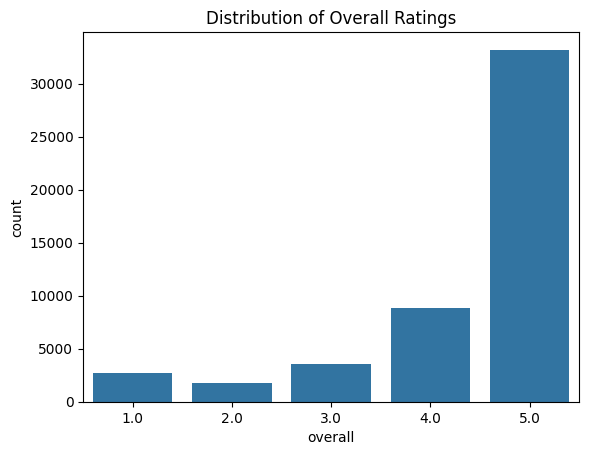

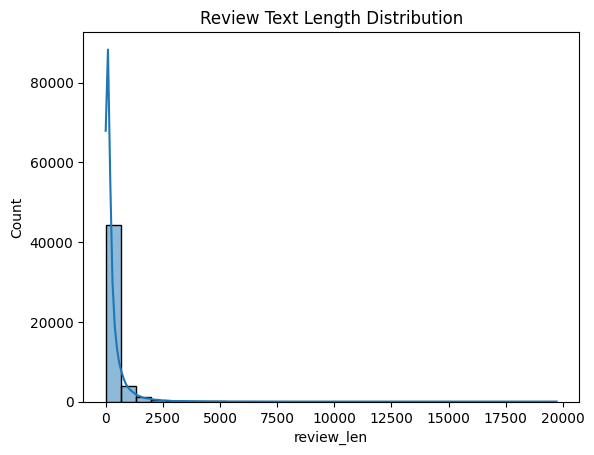

In [6]:
# Ratings distribution
sns.countplot(x='overall', data=df_sample)
plt.title("Distribution of Overall Ratings")
plt.show()

# Review length
df_sample['review_len'] = df_sample['reviewText'].str.len()
sns.histplot(df_sample['review_len'], bins=30, kde=True)
plt.title("Review Text Length Distribution")
plt.show()

In [7]:
df_sample[['overall', 'reviewerName', 'reviewText', 'summary']].sample(5)


,overall,reviewerName,reviewText,summary
24015,5.0,Bradley T. Riggleman,There is really no way other way to say this.....,Great Binoculars
15769,3.0,Vince the Radioman,This is a very good radio for folks just enter...,Good radio for beginners /nice price
37946,5.0,JDT,Excellent quality. Fits perfect. Good value.,Five Stars
21164,5.0,JTRup,I highly recommend this switch. I bought 2 of...,Perfect affordable home networking switch
40719,5.0,RhythmicGroove,Awesome!,Five Stars


<Axes: >

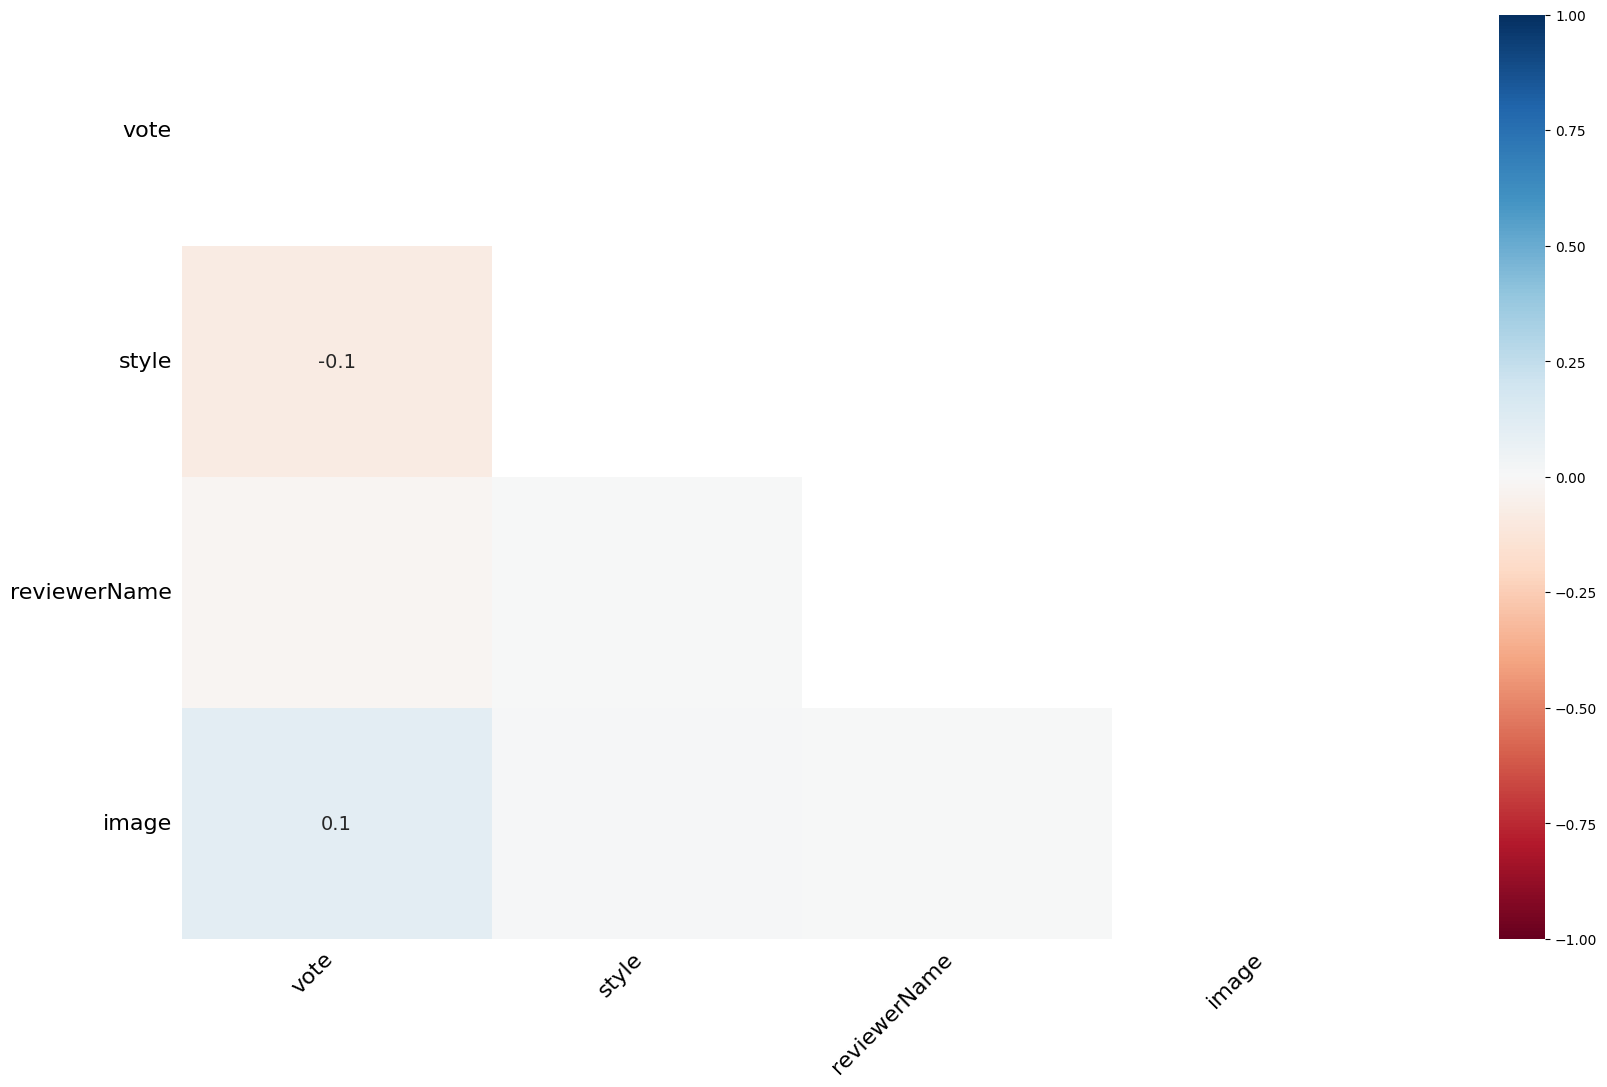

In [8]:

msno.heatmap(df_sample)

Ratings are heavily right-skewed (most are 5-star).

Most review texts are quite short (left-skewed).

very weak correlations between: vote and image: 0.1 (positive) vote and style: -0.1 (negative), can be considered noise

<Axes: title={'center': 'Normalized Rating Distribution'}, xlabel='overall'>

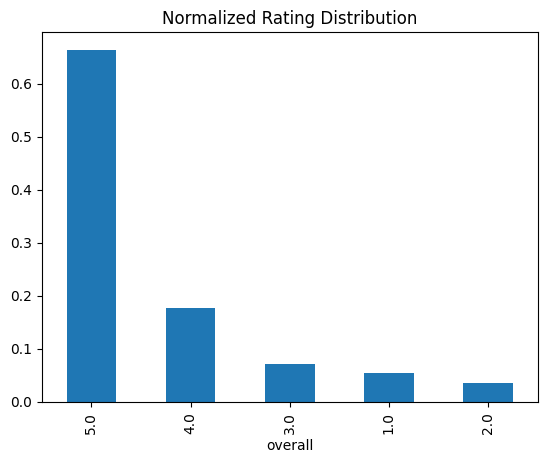

In [9]:
df_sample['overall'].value_counts(normalize=True).plot(kind='bar', title='Normalized Rating Distribution')


/tmp/ipykernel_1359/3375909872.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_pct.values, y=null_pct.index, palette='viridis')


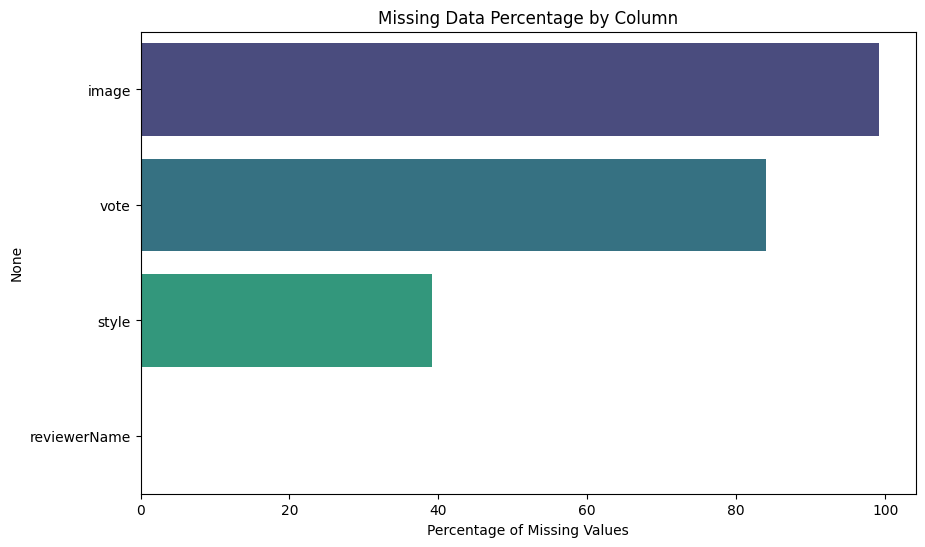

In [10]:
# Calculate null percentages
null_pct = df_sample.isnull().mean().sort_values(ascending=False) * 100

# Filter to show only columns with missing values
null_pct = null_pct[null_pct > 0]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=null_pct.values, y=null_pct.index, palette='viridis')
plt.xlabel("Percentage of Missing Values")
plt.title("Missing Data Percentage by Column")
plt.show()

as per database: vote - helpful votes of the review

Can signal review helpfulness when present; useful in ranking or weighting reviews.

style - a disctionary of the product metadata, e.g., "Format" is "Hardcover", can be used to enrich recommendations or filtering.

percentage of missing value for image is very high, Presence of user-uploaded images can correlate with engagement or trustworthiness, binary has_image can be used

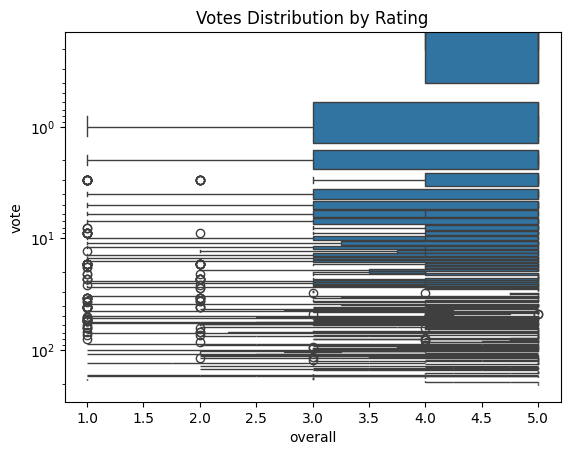

In [12]:

# Basic boxplot to explore helpful votes across star ratings
sns.boxplot(data=df_sample, x='overall', y='vote')

# Use a log scale for the y-axis to handle skewed vote counts
plt.yscale('log')

# Add a clear title
plt.title("Votes Distribution by Rating")

# Show the plot
plt.show()

chart is messy because data is not clean, leading to Overlapping outlier lines and an irregular distribution.

<Axes: title={'center': 'Average Review Length by Rating'}, xlabel='overall'>

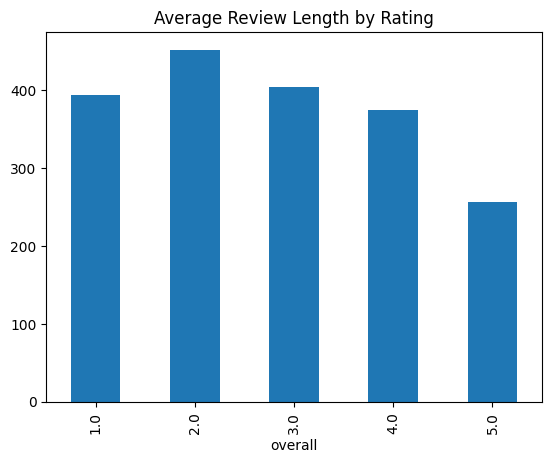

In [13]:
df_sample['review_len'] = df_sample['reviewText'].astype(str).apply(len)
df_sample.groupby('overall')['review_len'].mean().plot(kind='bar', title='Average Review Length by Rating')


higher ratings have shorter reviews

Text(0.5, 1.0, 'Rating distribution with/without Image')

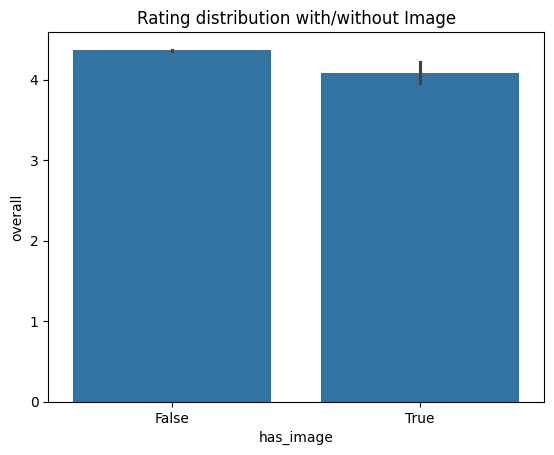

In [16]:
df_sample['has_image'] = df_sample['image'].notnull()
df_sample['has_style'] = df_sample['style'].notnull()
df_sample['has_vote'] = df_sample['vote'].notnull()

sns.barplot(data=df_sample, x='has_image', y='overall')
plt.title("Rating distribution with/without Image")


has_image seems to have no meaningful observations, rating distribution are similar for with and without image

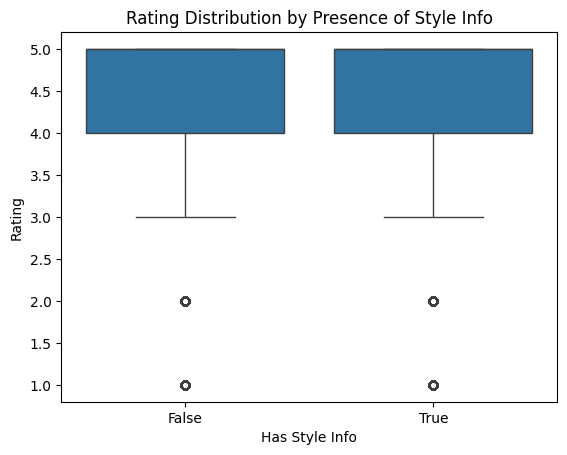

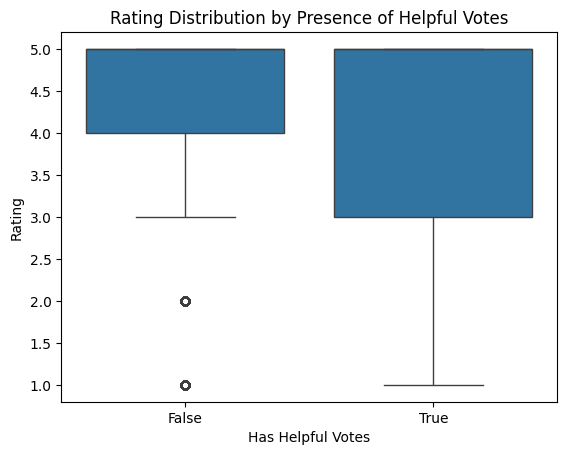

In [15]:
sns.boxplot(data=df_sample, x='has_style', y='overall')
plt.title("Rating Distribution by Presence of Style Info")
plt.xlabel("Has Style Info")
plt.ylabel("Rating")
plt.show()

sns.boxplot(data=df_sample, x='has_vote', y='overall')
plt.title("Rating Distribution by Presence of Helpful Votes")
plt.xlabel("Has Helpful Votes")
plt.ylabel("Rating")
plt.show()

Interpretation: Reviews with helpful votes tend to include more extreme or lower ratings.

Presence of style info doesn’t meaningfully affect user rating.

has_style was included as a binary flag to explore whether providing style information correlates with rating. 

Despite >80% missing values, the analysis helps validate whether this feature is useful. 

EDA showed minimal differences between groups, so it may be dropped in modeling.

In [25]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   overall         50000 non-null  float64
 1   vote            7981 non-null   object 
 2   verified        50000 non-null  bool   
 3   reviewTime      50000 non-null  object 
 4   reviewerID      50000 non-null  object 
 5   asin            50000 non-null  object 
 6   style           30404 non-null  object 
 7   reviewerName    49989 non-null  object 
 8   reviewText      50000 non-null  object 
 9   summary         50000 non-null  object 
 10  unixReviewTime  50000 non-null  int64  
 11  image           439 non-null    object 
 12  review_len      50000 non-null  int64  
 13  review_length   50000 non-null  int64  
 14  has_image       50000 non-null  bool   
 15  has_style       50000 non-null  bool   
dtypes: bool(3), float64(1), int64(3), object(9)
memory usage: 5.1+ MB


Text(0.5, 1.0, 'Distribution of Star Ratings')

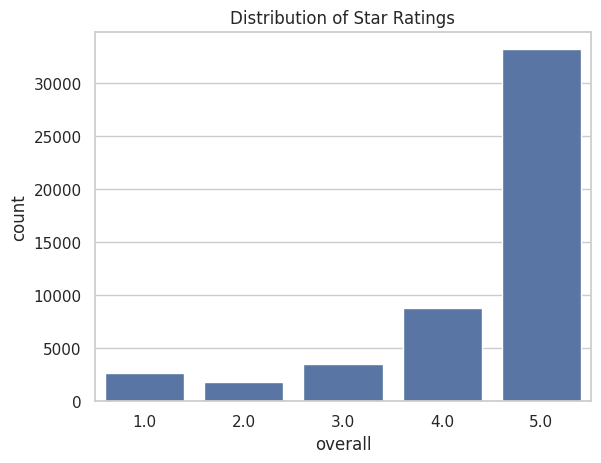

In [26]:
df_sample['vote'] = df_sample['vote'].str.replace(',', '').astype(float)
df_sample['reviewTime'] = pd.to_datetime(df_sample['reviewTime'])

sns.countplot(x='overall', data=df_sample)
plt.title('Distribution of Star Ratings')

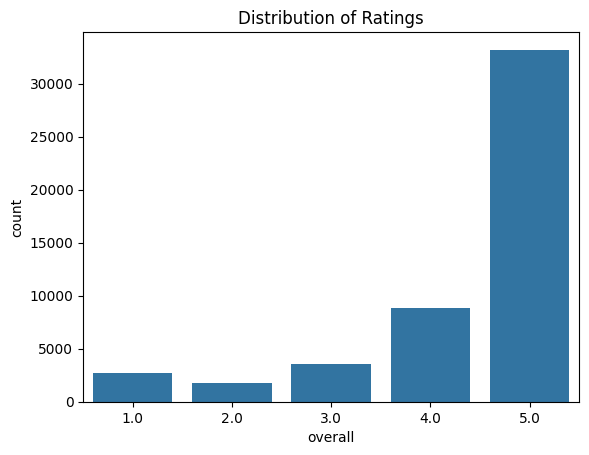

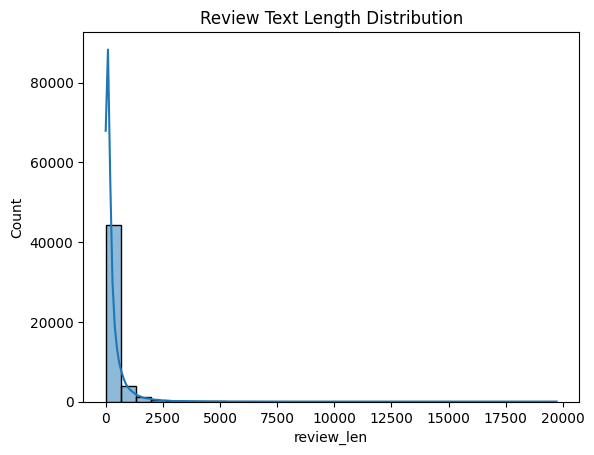

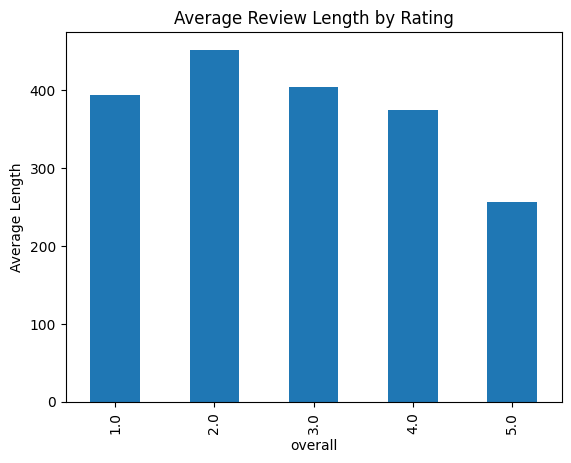

/tmp/ipykernel_1359/545157619.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_pct.values, y=null_pct.index, palette='viridis')


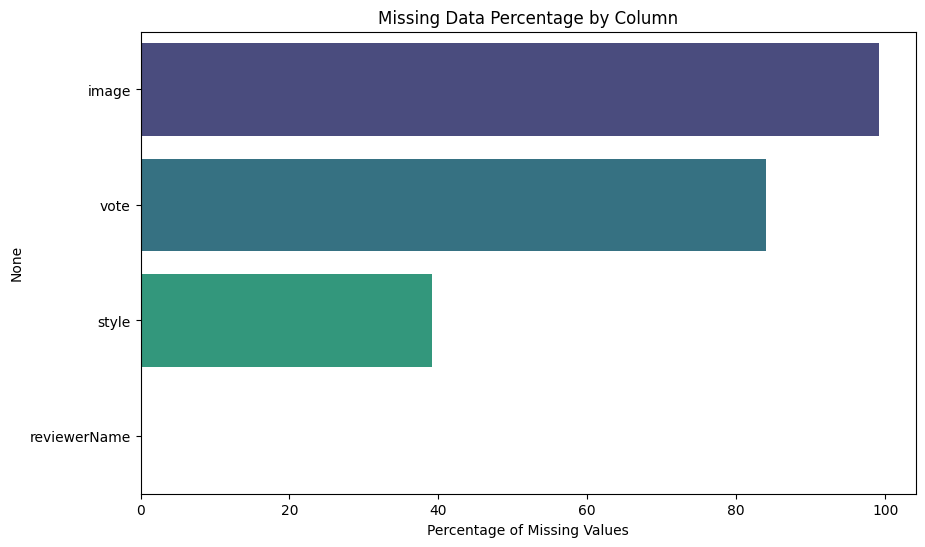

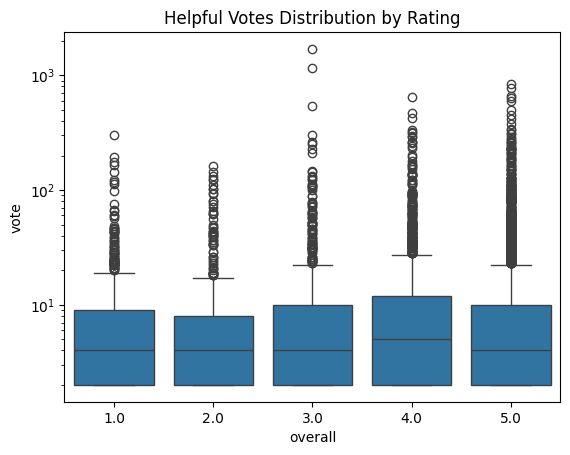

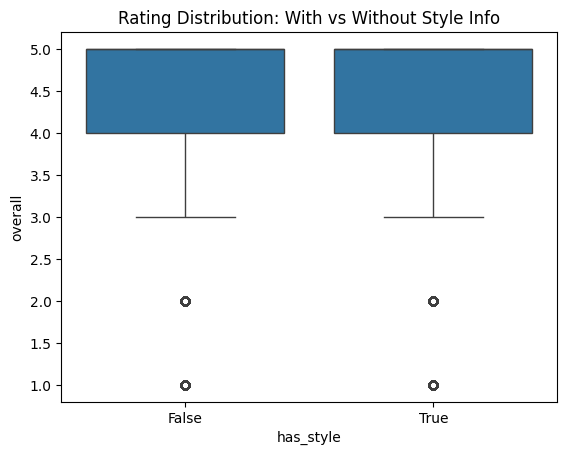

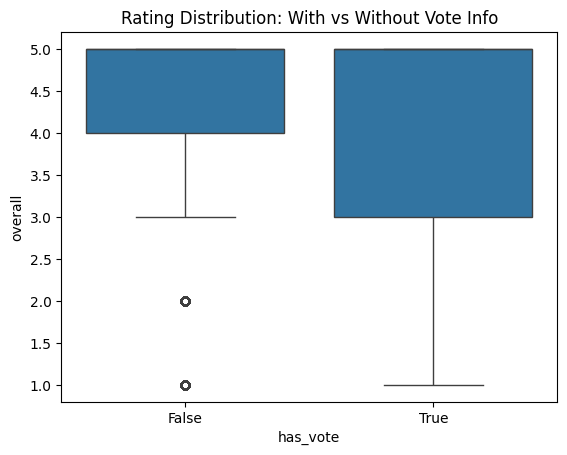

In [34]:

def run_basic_eda(df, target='overall', text_col='reviewText', vote_col='vote', datetime_col='reviewTime'):
    """
    Run exploratory data analysis (EDA) on a reviews dataset.
    """
    # Copy to avoid modifying original
    df = df.copy()
    
    # Clean vote column
    if vote_col in df.columns:
        df[vote_col] = df[vote_col].astype(str).str.replace(',', '', regex=False)
        df[vote_col] = pd.to_numeric(df[vote_col], errors='coerce')
    
    # Parse datetime
    if datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')

    # Add review length
    if text_col in df.columns:
        df['review_len'] = df[text_col].astype(str).apply(len)
    
    # Add binary flags
    df['has_style'] = df['style'].notnull() if 'style' in df.columns else False
    df['has_vote'] = df[vote_col].notnull() if vote_col in df.columns else False

    # Distribution of ratings
    sns.countplot(x=target, data=df)
    plt.title("Distribution of Ratings")
    plt.show()

    # Review length distribution
    sns.histplot(df['review_len'], bins=30, kde=True)
    plt.title("Review Text Length Distribution")
    plt.show()

    # Average review length by rating
    df.groupby(target)['review_len'].mean().plot(kind='bar', title='Average Review Length by Rating')
    plt.ylabel("Average Length")
    plt.show()

    # Missing data percentage bar chart
    null_pct = df.isnull().mean().sort_values(ascending=False) * 100
    null_pct = null_pct[null_pct > 0]
    if not null_pct.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=null_pct.values, y=null_pct.index, palette='viridis')
        plt.xlabel("Percentage of Missing Values")
        plt.title("Missing Data Percentage by Column")
        plt.show()

    # Boxplot of votes (skewed values)
    if vote_col in df.columns:
        sns.boxplot(data=df, x=target, y=vote_col)
        plt.yscale('log')
        plt.title("Helpful Votes Distribution by Rating")
        plt.show()

    # Boxplot: has_style vs rating
    sns.boxplot(data=df, x='has_style', y=target)
    plt.title("Rating Distribution: With vs Without Style Info")
    plt.show()

    # Boxplot: has_vote vs rating
    sns.boxplot(data=df, x='has_vote', y=target)
    plt.title("Rating Distribution: With vs Without Vote Info")
    plt.show()

    return df

df_sample = run_basic_eda(df_sample)

The full Electronics reviews dataset is stored in multiple partitioned .parquet files. To ensure the notebook remains fast and reproducible, EDA is demonstrated on a single part file (part_0000.parquet)